In [1]:
import sys
import pandas as pd
import numpy as np

print("Python:", sys.version)
print("Python executable:", sys.executable)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Python executable: C:\Users\HP\PycharmProjects\StreamingMediaIPModel\.venv\Scripts\python.exe
Pandas: 3.0.5
NumPy: 2.5.3


In [3]:
import pandas as pd

ANIME_PATH = "../data/raw/animes.csv"

anime_df = pd.read_csv(ANIME_PATH)

print("Anime dataset loaded successfully!")
print("Rows:", anime_df.shape[0])
print("Columns:", anime_df.shape[1])

Anime dataset loaded successfully!
Rows: 19311
Columns: 12


In [4]:
print("Columns in the anime dataset:\n")

for i, column in enumerate(anime_df.columns, start=1):
    print(f"{i}. {column}")


Columns in the anime dataset:

1. uid
2. title
3. synopsis
4. genre
5. aired
6. episodes
7. members
8. popularity
9. ranked
10. score
11. img_url
12. link


In [5]:
anime_df.head()

,uid,title,synopsis,genre,aired,episodes,members,popularity,ranked,score,img_url,link
0,28891,Haikyuu!! Second Season,Following their participation at the Inter-Hig...,"['Comedy', 'Sports', 'Drama', 'School', 'Shoun...","Oct 4, 2015 to Mar 27, 2016",25.0,489888,141,25.0,8.82,https://cdn.myanimelist.net/images/anime/9/766...,https://myanimelist.net/anime/28891/Haikyuu_Se...
1,23273,Shigatsu wa Kimi no Uso,Music accompanies the path of the human metron...,"['Drama', 'Music', 'Romance', 'School', 'Shoun...","Oct 10, 2014 to Mar 20, 2015",22.0,995473,28,24.0,8.83,https://cdn.myanimelist.net/images/anime/3/671...,https://myanimelist.net/anime/23273/Shigatsu_w...
2,34599,Made in Abyss,The Abyss—a gaping chasm stretching down into ...,"['Sci-Fi', 'Adventure', 'Mystery', 'Drama', 'F...","Jul 7, 2017 to Sep 29, 2017",13.0,581663,98,23.0,8.83,https://cdn.myanimelist.net/images/anime/6/867...,https://myanimelist.net/anime/34599/Made_in_Abyss
3,5114,Fullmetal Alchemist: Brotherhood,"""In order for something to be obtained, someth...","['Action', 'Military', 'Adventure', 'Comedy', ...","Apr 5, 2009 to Jul 4, 2010",64.0,1615084,4,1.0,9.23,https://cdn.myanimelist.net/images/anime/1223/...,https://myanimelist.net/anime/5114/Fullmetal_A...
4,31758,Kizumonogatari III: Reiketsu-hen,After helping revive the legendary vampire Kis...,"['Action', 'Mystery', 'Supernatural', 'Vampire']","Jan 6, 2017",1.0,214621,502,22.0,8.83,https://cdn.myanimelist.net/images/anime/3/815...,https://myanimelist.net/anime/31758/Kizumonoga...


In [6]:
anime_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19311 entries, 0 to 19310
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   uid         19311 non-null  int64  
 1   title       19311 non-null  str    
 2   synopsis    18336 non-null  str    
 3   genre       19311 non-null  str    
 4   aired       19311 non-null  str    
 5   episodes    18605 non-null  float64
 6   members     19311 non-null  int64  
 7   popularity  19311 non-null  int64  
 8   ranked      16099 non-null  float64
 9   score       18732 non-null  float64
 10  img_url     19131 non-null  str    
 11  link        19311 non-null  str    
dtypes: float64(3), int64(3), str(6)
memory usage: 1.8 MB


In [7]:
missing_count=anime_df.isna().sum()
missing_perc=(missing_count/len(anime_df))*100

missing_summary=pd.DataFrame({
    "missing_count":missing_count,
    "missing_percentage":missing_perc,
})
missing_summary

,missing_count,missing_percentage
uid,0,0.000000
title,0,0.000000
synopsis,975,5.048936
genre,0,0.000000
aired,0,0.000000
episodes,706,3.655947
members,0,0.000000
popularity,0,0.000000
ranked,3212,16.633007
score,579,2.998291


In [8]:
missing_score = anime_df[anime_df["score"].isna()]

print("Anime with missing scores:", len(missing_score))

missing_score[["uid", "title", "members", "popularity", "score"]].head(10)

Anime with missing scores: 579


,uid,title,members,popularity,score
1497,30532,Gundam Build Fighters OVA,2663,7290,NaN
1498,40242,Idomo,170,14113,NaN
1499,37962,IDOLiSH7: Second Beat!,4709,5972,NaN
1500,40046,ID:Invaded,17205,3494,NaN
1501,39725,I★Chu: Étoile Stage,626,10645,NaN
1502,40803,Hypnosis Mic: Division Rap Battle - Rhyme Anima,456,12081,NaN
1503,39736,Huangli Shi,470,11222,NaN
1504,40230,Housekishou Richard-shi no Nazo Kantei,7263,4984,NaN
1505,39730,Houkago Teibou Nisshi,1869,8698,NaN
1506,40815,Honzuki no Gekokujou: Shisho ni Naru Tame ni w...,11900,4612,NaN


In [9]:
missing_ranked = anime_df[anime_df["ranked"].isna()]

print("Anime with missing rankings:", len(missing_ranked))

missing_ranked[["uid", "title", "members", "popularity", "ranked", "score"]].head(10)

Anime with missing rankings: 3212


,uid,title,members,popularity,ranked,score
1497,30532,Gundam Build Fighters OVA,2663,7290,NaN,NaN
1498,40242,Idomo,170,14113,NaN,NaN
1499,37962,IDOLiSH7: Second Beat!,4709,5972,NaN,NaN
1500,40046,ID:Invaded,17205,3494,NaN,NaN
1501,39725,I★Chu: Étoile Stage,626,10645,NaN,NaN
1502,40803,Hypnosis Mic: Division Rap Battle - Rhyme Anima,456,12081,NaN,NaN
1503,39736,Huangli Shi,470,11222,NaN,NaN
1504,40230,Housekishou Richard-shi no Nazo Kantei,7263,4984,NaN,NaN
1505,39730,Houkago Teibou Nisshi,1869,8698,NaN,NaN
1506,40815,Honzuki no Gekokujou: Shisho ni Naru Tame ni w...,11900,4612,NaN,NaN


In [10]:
anime_df[["episodes", "members", "popularity", "ranked", "score"]].describe()

,episodes,members,popularity,ranked,score
count,18605.000000,1.931100e+04,19311.000000,16099.000000,18732.000000
mean,11.460414,3.472609e+04,7720.830304,6866.524194,6.436107
std,47.950386,1.121772e+05,4676.786104,4390.018768,1.007941
min,1.000000,2.500000e+01,1.000000,1.000000,1.250000
25%,1.000000,3.880000e+02,3725.000000,2895.500000,5.770000
50%,2.000000,2.389000e+03,7539.000000,6963.000000,6.410000
75%,12.000000,1.450150e+04,11613.000000,10601.500000,7.150000
max,3057.000000,1.871043e+06,16338.000000,14675.000000,9.230000


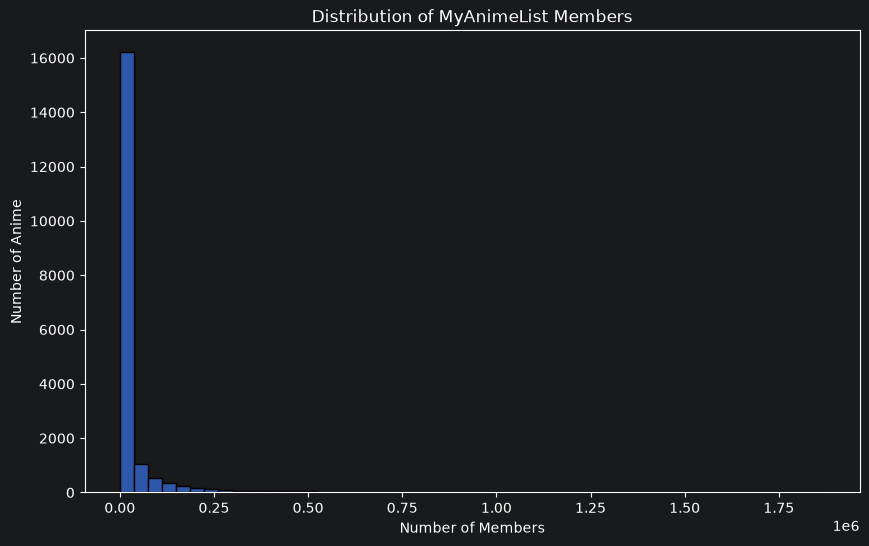

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(
    anime_df["members"],
    bins=50
)

plt.title("Distribution of MyAnimeList Members")
plt.xlabel("Number of Members")
plt.ylabel("Number of Anime")

plt.show()

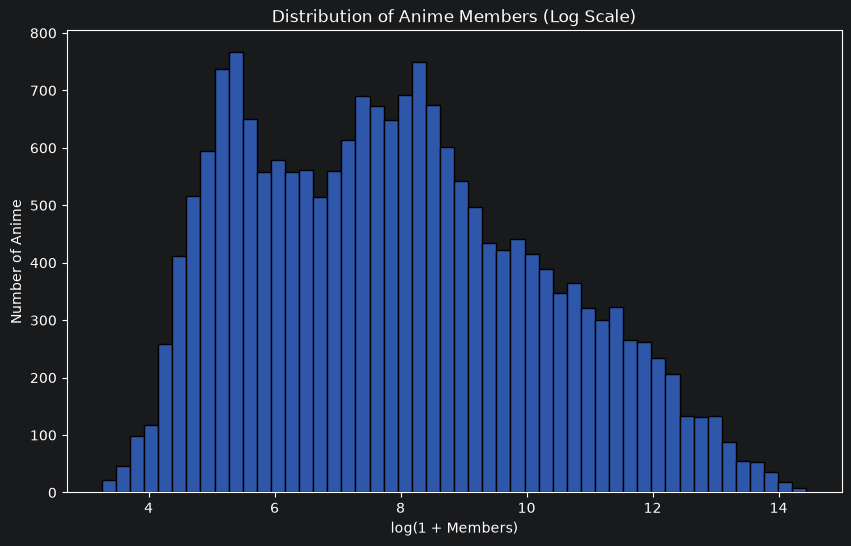

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(
    np.log1p(anime_df["members"]),
    bins=50
)

plt.title("Distribution of Anime Members (Log Scale)")
plt.xlabel("log(1 + Members)")
plt.ylabel("Number of Anime")

plt.show()

In [16]:
#Reviews.csv is the file

In [14]:
REVIEWS_PATH = "../data/raw/reviews.csv"

reviews_df = pd.read_csv(REVIEWS_PATH)

print("Reviews dataset loaded successfully!")
print("Rows:", reviews_df.shape[0])
print("Columns:", reviews_df.shape[1])

Reviews dataset loaded successfully!
Rows: 192112
Columns: 7


In [17]:
print("Columns in the reviews dataset:\n")

for i, column in enumerate(reviews_df.columns, start=1):
    print(f"{i}. {column}")

Columns in the reviews dataset:

1. uid
2. profile
3. anime_uid
4. text
5. score
6. scores
7. link


In [18]:
print("Reviews dataset columns and data types:\n")

for column in reviews_df.columns:
    print(f"{column:12} → {reviews_df[column].dtype}")

Reviews dataset columns and data types:

uid          → int64
profile      → str
anime_uid    → int64
text         → str
score        → int64
scores       → str
link         → str


In [19]:
missing_reviews=reviews_df.isna().sum()
missing_reviews

uid          0
profile      0
anime_uid    0
text         0
score        0
scores       0
link         0
dtype: int64

In [20]:
reviews_df.head()

,uid,profile,anime_uid,text,score,scores,link
0,255938,DesolatePsyche,34096,\n \n \n \n ...,8,"{'Overall': '8', 'Story': '8', 'Animation': '8...",https://myanimelist.net/reviews.php?id=255938
1,259117,baekbeans,34599,\n \n \n \n ...,10,"{'Overall': '10', 'Story': '10', 'Animation': ...",https://myanimelist.net/reviews.php?id=259117
2,253664,skrn,28891,\n \n \n \n ...,7,"{'Overall': '7', 'Story': '7', 'Animation': '9...",https://myanimelist.net/reviews.php?id=253664
3,8254,edgewalker00,2904,\n \n \n \n ...,9,"{'Overall': '9', 'Story': '9', 'Animation': '9...",https://myanimelist.net/reviews.php?id=8254
4,291149,aManOfCulture99,4181,\n \n \n \n ...,10,"{'Overall': '10', 'Story': '10', 'Animation': ...",https://myanimelist.net/reviews.php?id=291149


In [21]:
print("Review text:\n")
print(reviews_df.loc[0, "text"])

print("\nReviewer score:", reviews_df.loc[0, "score"])

print("\nDetailed scores:\n")
print(reviews_df.loc[0, "scores"])

Review text:


           
         
           
             
           
         
         
           more pics 
         
       
         
       
         
           Overall 
           8 
         
         
           Story 
           8 
         
                   
             Animation 
             8 
           
           
             Sound 
             10 
           
                 
           Character 
           9 
         
         
           Enjoyment 
           8 
         
       
     

                    
    First things first. My "reviews" system is explained on a blog entry. Which can be found through my profile. 
------ 
 
I'm going to keep this "review" more of a opinion of Gintama's overall and then this season specific. 
 
Anyhow. What I have always loved regarding Gintama, is its content of everything. I love the comedy, its absurd, random, can be vile, dirty, sweet, anyhow, everything. Have laughed countless times in this franchise. Also th

In [22]:
reviews_df["score"].describe()

count    192112.000000
mean          7.570235
std           2.255167
min           0.000000
25%           6.000000
50%           8.000000
75%           9.000000
max          11.000000
Name: score, dtype: float64

In [23]:
print("Review score frequencies:\n")

print(reviews_df["score"].value_counts().sort_index())

Review score frequencies:

score
0         1
1      3561
2      3815
3      7204
4      7537
5     11154
6     16497
7     25826
8     34814
9     39695
10    42007
11        1
Name: count, dtype: int64


In [24]:
unusual_scores = reviews_df[reviews_df["score"].isin([0, 11])]

unusual_scores[["uid", "profile", "anime_uid", "score", "text"]]

,uid,profile,anime_uid,score,text
63039,6424,Jackimus,226,0,\n \n \n \n ...
119190,252847,LeBrains,413,11,\n \n \n \n ...


In [25]:
print("Score:", reviews_df.loc[63039, "score"])
print("Detailed scores:", reviews_df.loc[63039, "scores"])

print("\n" + "-" * 60 + "\n")

print("Score:", reviews_df.loc[119190, "score"])
print("Detailed scores:", reviews_df.loc[119190, "scores"])


Score: 0
Detailed scores: {'Overall': '0', 'Story': '0', 'Animation': '0', 'Sound': '0', 'Character': '0', 'Enjoyment': '0'}

------------------------------------------------------------

Score: 11
Detailed scores: {'Overall': '11', 'Story': '11', 'Animation': '11', 'Sound': '11', 'Character': '11', 'Enjoyment': '11'}


In [26]:
anime_ids = set(anime_df["uid"])

matched_reviews = reviews_df["anime_uid"].isin(anime_ids)

print("Reviews matching an anime:", matched_reviews.sum())
print("Reviews without matching anime:", (~matched_reviews).sum())

Reviews matching an anime: 192112
Reviews without matching anime: 0


In [27]:
review_counts = reviews_df["anime_uid"].value_counts()

print("Number of anime with at least one review:", len(review_counts))
print("Maximum reviews for one anime:", review_counts.max())
print("Median reviews per reviewed anime:", review_counts.median())

Number of anime with at least one review: 8113
Maximum reviews for one anime: 1708
Median reviews per reviewed anime: 4.0


In [28]:
top_reviewed = (
    review_counts
    .reset_index()
    .rename(columns={"count": "review_count", "anime_uid": "uid"})
    .merge(
        anime_df[["uid", "title", "members", "score"]],
        on="uid",
        how="left"
    )
    .sort_values("review_count", ascending=False)
)

top_reviewed.head(10)

,uid,review_count,title,members,score
0,1535,1708,Death Note,1871043,8.65
1,1535,1708,Death Note,1871043,8.65
2,9253,1558,Steins;Gate,1331710,9.11
3,9253,1558,Steins;Gate,1331710,9.11
4,32281,1436,Kimi no Na wa.,1139878,9.09
5,32281,1436,Kimi no Na wa.,1139878,9.09
6,11757,1292,Sword Art Online,1657823,7.49
7,5114,1274,Fullmetal Alchemist: Brotherhood,1615084,9.23
8,5114,1274,Fullmetal Alchemist: Brotherhood,1615084,9.23
9,4181,1194,Clannad: After Story,740101,8.97


In [29]:
review_counts_df = (
    reviews_df.groupby("anime_uid")
    .size()
    .reset_index(name="review_count")
)

top_reviewed = (
    review_counts_df
    .merge(
        anime_df[["uid", "title", "members", "score"]],
        left_on="anime_uid",
        right_on="uid",
        how="left"
    )
    .sort_values("review_count", ascending=False)
)

top_reviewed.head(10)

,anime_uid,review_count,uid,title,members,score
1601,1535,1708,1535,Death Note,1871043,8.65
1600,1535,1708,1535,Death Note,1871043,8.65
5123,9253,1558,9253,Steins;Gate,1331710,9.11
5124,9253,1558,9253,Steins;Gate,1331710,9.11
8315,32281,1436,32281,Kimi no Na wa.,1139878,9.09
8314,32281,1436,32281,Kimi no Na wa.,1139878,9.09
5755,11757,1292,11757,Sword Art Online,1657823,7.49
3969,5114,1274,5114,Fullmetal Alchemist: Brotherhood,1615084,9.23
3970,5114,1274,5114,Fullmetal Alchemist: Brotherhood,1615084,9.23
3604,4181,1194,4181,Clannad: After Story,740101,8.97


In [30]:
duplicate_uids = anime_df[anime_df["uid"].duplicated(keep=False)]

print("Rows with duplicate anime UIDs:", len(duplicate_uids))
print("Number of duplicated UIDs:", duplicate_uids["uid"].nunique())

duplicate_uids[["uid", "title"]].head(20)


Rows with duplicate anime UIDs: 6140
Number of duplicated UIDs: 3045


,uid,title
0,28891,Haikyuu!! Second Season
1,23273,Shigatsu wa Kimi no Uso
2,34599,Made in Abyss
3,5114,Fullmetal Alchemist: Brotherhood
4,31758,Kizumonogatari III: Reiketsu-hen
5,37510,Mob Psycho 100 II
6,199,Sen to Chihiro no Kamikakushi
7,38000,Kimetsu no Yaiba
8,35247,Owarimonogatari 2nd Season
9,2904,Code Geass: Hangyaku no Lelouch R2


In [31]:
anime_df[anime_df["uid"] == 1535][
    ["uid", "title", "episodes", "members", "popularity", "ranked", "score"]
]

,uid,title,episodes,members,popularity,ranked,score
740,1535,Death Note,37.0,1871043,1,52.0,8.65
17762,1535,Death Note,37.0,1871043,1,52.0,8.65


In [32]:
exact_duplicates = anime_df.duplicated().sum()

print("Exact duplicate rows:", exact_duplicates)


Exact duplicate rows: 2943


In [33]:
duplicate_uid_groups = (
    anime_df[anime_df["uid"].duplicated(keep=False)]
    .sort_values("uid")
)

non_identical_duplicates = duplicate_uid_groups[
    ~duplicate_uid_groups.duplicated(keep=False)
]

print("Rows in duplicated UID groups:", len(duplicate_uid_groups))
print("Rows that are not exact duplicate rows:", len(non_identical_duplicates))

non_identical_duplicates[["uid", "title", "episodes", "members", "popularity", "ranked", "score"]].head(20)

Rows in duplicated UID groups: 6140
Rows that are not exact duplicate rows: 254


,uid,title,episodes,members,popularity,ranked,score
5079,26,Texhnolyze,22.0,154089,720,1058.0,7.74
3112,60,Chrno Crusade,24.0,182751,593,1069.0,7.73
4814,71,Full Metal Panic!,24.0,366816,244,1095.0,7.72
4942,87,Mobile Suit Gundam: Char's Counterattack,1.0,29228,2603,1081.0,7.73
4935,95,Turn A Gundam,50.0,30386,2544,1085.0,7.73
3104,123,Fushigi Yuugi,52.0,84377,1291,1071.0,7.73
7737,150,Blood+,50.0,284268,344,1066.0,7.73
3133,255,Jungle wa Itsumo Hare nochi Guu Final,7.0,8743,4581,1098.0,7.72
5086,290,Seikai no Monshou,13.0,38185,2247,1054.0,7.74
7736,324,Kidou Keisatsu Patlabor: On Television,47.0,24998,2846,1099.0,7.72


In [34]:
non_identical_duplicates.sort_values("uid").head(30)

,uid,title,synopsis,genre,aired,episodes,members,popularity,ranked,score,img_url,link
5079,26,Texhnolyze,"Texhnolyze takes place in the city of Lux, a ...","['Action', 'Sci-Fi', 'Psychological', 'Drama']","Apr 17, 2003 to Sep 25, 2003",22.0,154089,720,1058.0,7.74,https://cdn.myanimelist.net/images/anime/3/181...,https://myanimelist.net/anime/26/Texhnolyze
3112,60,Chrno Crusade,The 1920s was a decade of great change and uph...,"['Action', 'Demons', 'Historical', 'Romance', ...","Nov 25, 2003 to Jun 10, 2004",24.0,182751,593,1069.0,7.73,https://cdn.myanimelist.net/images/anime/13/14...,https://myanimelist.net/anime/60/Chrno_Crusade
4814,71,Full Metal Panic!,Equipped with cutting-edge weaponry and specia...,"['Action', 'Military', 'Sci-Fi', 'Comedy', 'Me...","Jan 8, 2002 to Jun 18, 2002",24.0,366816,244,1095.0,7.72,https://cdn.myanimelist.net/images/anime/2/752...,https://myanimelist.net/anime/71/Full_Metal_Panic
4942,87,Mobile Suit Gundam: Char's Counterattack,The year is Universal Century 0093. Char Aznab...,"['Military', 'Sci-Fi', 'Space', 'Drama', 'Mecha']","Mar 12, 1988",1.0,29228,2603,1081.0,7.73,https://cdn.myanimelist.net/images/anime/1523/...,https://myanimelist.net/anime/87/Mobile_Suit_G...
4935,95,Turn A Gundam,"It is the Correct Century, two millenniums aft...","['Action', 'Military', 'Sci-Fi', 'Adventure', ...","Apr 9, 1999 to Apr 14, 2000",50.0,30386,2544,1085.0,7.73,https://cdn.myanimelist.net/images/anime/4/783...,https://myanimelist.net/anime/95/Turn_A_Gundam
3104,123,Fushigi Yuugi,"While visiting the National Library, junior-hi...","['Adventure', 'Fantasy', 'Magic', 'Martial Art...","Apr 6, 1995 to Mar 28, 1996",52.0,84377,1291,1071.0,7.73,https://cdn.myanimelist.net/images/anime/2/201...,https://myanimelist.net/anime/123/Fushigi_Yuugi
7737,150,Blood+,Saya Otonashi is a seemingly ordinary girl liv...,"['Action', 'Military', 'Mystery', 'Horror', 'S...","Oct 8, 2005 to Sep 23, 2006",50.0,284268,344,1066.0,7.73,https://cdn.myanimelist.net/images/anime/10/10...,https://myanimelist.net/anime/150/Blood_
3133,255,Jungle wa Itsumo Hare nochi Guu Final,Haré's family receives a video letter from Wed...,"['Slice of Life', 'Comedy']","Dec 21, 2003 to Jun 25, 2004",7.0,8743,4581,1098.0,7.72,https://cdn.myanimelist.net/images/anime/6/145...,https://myanimelist.net/anime/255/Jungle_wa_It...
5086,290,Seikai no Monshou,"In the distant future, humanity is under attac...","['Action', 'Military', 'Sci-Fi', 'Space', 'Rom...","Jan 3, 1999 to Mar 28, 1999",13.0,38185,2247,1054.0,7.74,https://cdn.myanimelist.net/images/anime/1493/...,https://myanimelist.net/anime/290/Seikai_no_Mo...
7736,324,Kidou Keisatsu Patlabor: On Television,"In the future, advanced robotics has created h...","['Comedy', 'Mecha', 'Police', 'Sci-Fi']","Oct 11, 1989 to Sep 26, 1990",47.0,24998,2846,1099.0,7.72,https://cdn.myanimelist.net/images/anime/7/592...,https://myanimelist.net/anime/324/Kidou_Keisat...


In [35]:
remaining_duplicate_counts = (
    non_identical_duplicates["uid"]
    .value_counts()
)

print("Number of UIDs involved:", len(remaining_duplicate_counts))
print("\nRecords per UID:")
print(remaining_duplicate_counts.value_counts().sort_index())

Number of UIDs involved: 152

Records per UID:
count
1     50
2    102
Name: count, dtype: int64


In [36]:
anime_df[anime_df["uid"] == 26].T

,1031,5079,19245
uid,26,26,26
title,Texhnolyze,Texhnolyze,Texhnolyze
synopsis,"Texhnolyze takes place in the city of Lux, a ...","Texhnolyze takes place in the city of Lux, a ...","Texhnolyze takes place in the city of Lux, a ..."
genre,"['Action', 'Sci-Fi', 'Psychological', 'Drama']","['Action', 'Sci-Fi', 'Psychological', 'Drama']","['Action', 'Sci-Fi', 'Psychological', 'Drama']"
aired,"Apr 17, 2003 to Sep 25, 2003","Apr 17, 2003 to Sep 25, 2003","Apr 17, 2003 to Sep 25, 2003"
episodes,22.0,22.0,22.0
members,154140,154089,154140
popularity,720,720,720
ranked,1058.0,1058.0,1058.0
score,7.74,7.74,7.74


In [38]:
duplicate_summary = []

for uid, group in anime_df[anime_df["uid"].duplicated(keep=False)].groupby("uid"):
    duplicate_summary.append({
        "uid": uid,
        "rows": len(group),
        "title_diff": group["title"].nunique(),
        "members_diff": group["members"].nunique(),
        "score_diff": group["score"].nunique(),
        "popularity_diff": group["popularity"].nunique(),
        "ranked_diff": group["ranked"].nunique(),
        "episodes_diff": group["episodes"].nunique()
    })

duplicate_summary_df = pd.DataFrame(duplicate_summary)

duplicate_summary_df.head(10)

,uid,rows,title_diff,members_diff,score_diff,popularity_diff,ranked_diff,episodes_diff
0,1,2,1,1,1,1,1,1
1,5,2,1,1,1,1,1,1
2,6,2,1,1,1,1,1,1
3,15,2,1,1,1,1,1,1
4,16,2,1,1,1,1,1,1
5,18,2,1,1,1,1,1,1
6,19,2,1,1,1,1,1,1
7,20,2,1,1,1,1,1,1
8,21,2,1,1,1,1,1,0
9,22,2,1,1,1,1,1,1


In [40]:
columns_checked = [
    "title",
    "members",
    "score",
    "popularity",
    "ranked",
    "episodes"
]

for column in columns_checked:
    varying = duplicate_summary_df[f"{column}_diff"] > 1
    print(f"{column:12} → {varying.sum()} duplicated UID groups have different values")

title        → 0 duplicated UID groups have different values
members      → 138 duplicated UID groups have different values
score        → 0 duplicated UID groups have different values
popularity   → 53 duplicated UID groups have different values
ranked       → 10 duplicated UID groups have different values
episodes     → 0 duplicated UID groups have different values


In [41]:
for uid in [26, 1535, 9253]:
    print(f"\nUID: {uid}")
    print(anime_df[anime_df["uid"] == uid].index.tolist())


UID: 26
[1031, 5079, 19245]

UID: 1535
[740, 17762]

UID: 9253
[773, 18281]


In [42]:
unique_anime_count = anime_df["uid"].nunique()

print("Total anime rows:", len(anime_df))
print("Unique anime UIDs:", unique_anime_count)
print("Duplicate rows:", len(anime_df) - unique_anime_count)

Total anime rows: 19311
Unique anime UIDs: 16216
Duplicate rows: 3095


In [43]:
anime_clean = anime_df.drop_duplicates(subset="uid", keep="first").copy()

print("Original rows:", len(anime_df))
print("Cleaned rows:", len(anime_clean))
print("Unique UIDs:", anime_clean["uid"].nunique())

Original rows: 19311
Cleaned rows: 16216
Unique UIDs: 16216


In [44]:
print("Duplicate UIDs remaining:", anime_clean["uid"].duplicated().sum())
print("Duplicate rows remaining:", anime_clean.duplicated().sum())

Duplicate UIDs remaining: 0
Duplicate rows remaining: 0


In [45]:
print("Duplicate review UIDs:", reviews_df["uid"].duplicated().sum())
print("Duplicate review rows:", reviews_df.duplicated().sum())

Duplicate review UIDs: 61593
Duplicate review rows: 61593


In [46]:
unique_review_count = reviews_df["uid"].nunique()

print("Total review rows:", len(reviews_df))
print("Unique review UIDs:", unique_review_count)
print("Duplicate rows:", len(reviews_df) - unique_review_count)

Total review rows: 192112
Unique review UIDs: 130519
Duplicate rows: 61593


In [47]:
reviews_clean = reviews_df.drop_duplicates(subset="uid", keep="first").copy()

print("Original review rows:", len(reviews_df))
print("Cleaned review rows:", len(reviews_clean))
print("Unique review UIDs:", reviews_clean["uid"].nunique())

Original review rows: 192112
Cleaned review rows: 130519
Unique review UIDs: 130519


In [50]:
print("=== LAST DATA CHECK ===\n")

print("Anime dataset")
print("Rows:", len(anime_clean))
print("Unique anime UIDs:", anime_clean["uid"].nunique())
print("Duplicate UIDs:", anime_clean["uid"].duplicated().sum())

print("\nReviews dataset")
print("Rows:", len(reviews_clean))
print("Unique review UIDs:", reviews_clean["uid"].nunique())
print("Duplicate review UIDs:", reviews_clean["uid"].duplicated().sum())

print("\nReview to Anime matching")
print(
    "Reviews without matching anime:",
    (~reviews_clean["anime_uid"].isin(anime_clean["uid"])).sum()
)


=== LAST DATA CHECK ===

Anime dataset
Rows: 16216
Unique anime UIDs: 16216
Duplicate UIDs: 0

Reviews dataset
Rows: 130519
Unique review UIDs: 130519
Duplicate review UIDs: 0

Review to Anime matching
Reviews without matching anime: 0
